In [1]:
!pip install netCDF4 dask xarray

import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from google.colab import drive

drive.mount('/content/drive')

folder_path = '/content/drive/MyDrive/Dataset_AODN_2022/*.nc'

print("Membaca data NetCDF...")
ds = xr.open_mfdataset(folder_path, combine='by_coords')

ds_unique = ds.drop_duplicates(dim='TIME')
ds_filtered = ds_unique.sel(TIME=slice('2022-01-01', '2022-04-30'))

print("Melakukan resampling 3-Hourly...")
ds_3h = ds_filtered.resample(TIME='3h').mean()

dimensi_selain_waktu = [dim for dim in ds_3h.dims if dim != 'TIME']
ds_1d = ds_3h.mean(dim=dimensi_selain_waktu)

df = ds_1d.to_dataframe().reset_index()

kolom_tersedia = ['TIME', 'EKTH', 'DIRECTION', 'HS_PART', 'WP_PART', 'WSPD_ECMWF', 'WDIR_ECMWF', 'BOT_DEPTH', 'DIST2COAST']
kolom_dipakai = [col for col in kolom_tersedia if col in df.columns]
df = df[kolom_dipakai].dropna()

threshold_anomali = df['HS_PART'].quantile(0.90)
df['Outlier_Label'] = np.where(df['HS_PART'] >= threshold_anomali, 1, 0)

X = df.drop(columns=['Outlier_Label', 'HS_PART', 'TIME'], errors='ignore')
y = df['Outlier_Label']

print(f"\nData siap! Total observasi: {len(df)}")
print(f"Distribusi Target (Outlier_Label):\n{y.value_counts().to_string()}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.2 MB/s eta 0:00:00
Mounted at /content/drive
Membaca data NetCDF...
Melakukan resampling 3-Hourly...

Data siap! Total observasi: 697
Distribusi Target (Outlier_Label):
Outlier_Label
0    627
1     70


In [2]:
df.to_csv('/content/drive/MyDrive/Dataset_AODN_2022/AODN_Cleaned_3H.csv', index=False)
print("Data berhasil disimpan ke CSV!")

Data berhasil disimpan ke CSV!


Jumlah Data Training: 557
Jumlah Data Testing:  140


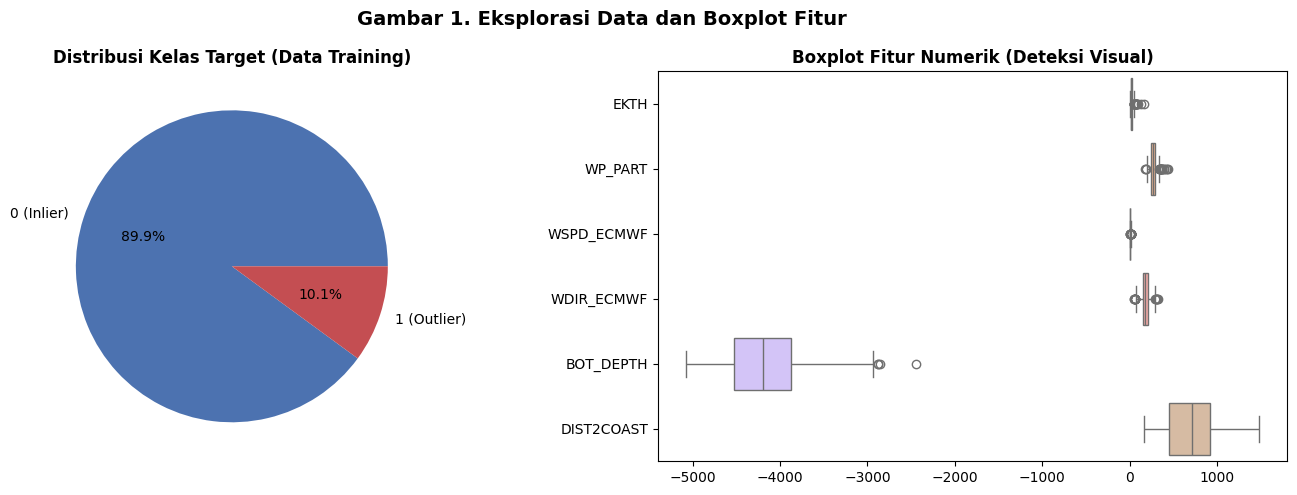

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Jumlah Data Training: {X_train.shape[0]}")
print(f"Jumlah Data Testing:  {X_test.shape[0]}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
y_train.value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#4c72b0', '#c44e52'], ax=axes[0], labels=['0 (Inlier)', '1 (Outlier)'])
axes[0].set_title('Distribusi Kelas Target (Data Training)', fontweight='bold')
axes[0].set_ylabel('')

sns.boxplot(data=X_train, ax=axes[1], palette='pastel', orient='h')
axes[1].set_title('Boxplot Fitur Numerik (Deteksi Visual)', fontweight='bold')

plt.suptitle('Gambar 1. Eksplorasi Data dan Boxplot Fitur', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
from sklearn.ensemble import IsolationForest

def get_modified_zscore_mask(df, threshold=3.5):
    median = df.median()
    mad = (df - median).abs().median().replace(0, 1e-6)
    mod_zscore = 0.6745 * (df - median) / mad

    return (mod_zscore.abs() > threshold).any(axis=1)

mask_modz = get_modified_zscore_mask(X_train)

iso = IsolationForest(contamination=0.05, random_state=42)
preds_iso = iso.fit_predict(X_train)
mask_iso = (preds_iso == -1) # -1 adalah outlier

summary_deteksi = pd.DataFrame({
    'Metode': ['Modified Z-Score (|Mi| > 3.5)', 'Isolation Forest'],
    'Outlier Terdeteksi': [mask_modz.sum(), mask_iso.sum()],
    'Persentase (%)': [(mask_modz.mean()*100).round(2), (mask_iso.mean()*100).round(2)]
})

print("Tabel 1. Jumlah Outlier per Metode Deteksi (Data Training)\n")
print(summary_deteksi.to_string(index=False))

Tabel 1. Jumlah Outlier per Metode Deteksi (Data Training)

                       Metode  Outlier Terdeteksi  Persentase (%)
Modified Z-Score (|Mi| > 3.5)                  27            4.85
             Isolation Forest                  28            5.03


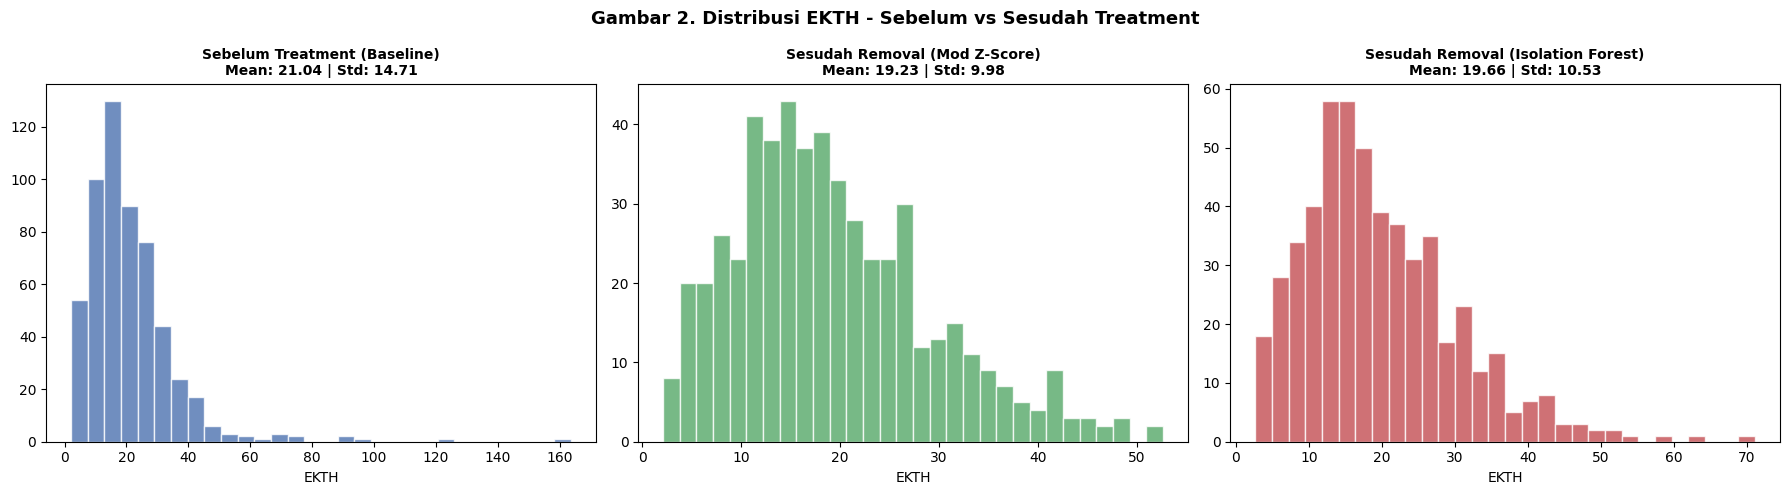

In [5]:
# Dataset bersih 1 (Modified Z-Score)
X_train_modz = X_train[~mask_modz].copy()
y_train_modz = y_train[~mask_modz].copy()

# Dataset bersih 2 (Isolation Forest)
X_train_iso = X_train[~mask_iso].copy()
y_train_iso = y_train[~mask_iso].copy()

fitur_viz = X.columns[0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
configs_viz = [
    ('Sebelum Treatment (Baseline)', X_train[fitur_viz], '#4c72b0'),
    ('Sesudah Removal (Mod Z-Score)', X_train_modz[fitur_viz], '#55a868'),
    ('Sesudah Removal (Isolation Forest)', X_train_iso[fitur_viz], '#c44e52')
]

for ax, (label, data, color) in zip(axes, configs_viz):
    ax.hist(data, bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{label}\nMean: {data.mean():.2f} | Std: {data.std():.2f}', fontweight='bold', fontsize=10)
    ax.set_xlabel(fitur_viz)

plt.suptitle(f'Gambar 2. Distribusi {fitur_viz} - Sebelum vs Sesudah Treatment', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(model, X_te, y_te, model_name):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    return {
        'Model (Strategi Treatment)': model_name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, average='macro'),
        'Recall': recall_score(y_te, y_pred, average='macro'),
        'F1-Score': f1_score(y_te, y_pred, average='macro'),
        'AUC-ROC': roc_auc_score(y_te, y_proba)
    }, model

# Skenario Data Training
skenario = {
    'Baseline (Tanpa Treatment)': (X_train, y_train),
    'Removal - Modified Z-Score': (X_train_modz, y_train_modz),
    'Removal - Isolation Forest': (X_train_iso, y_train_iso)
}

hasil_evaluasi = []
model_tersimpan = {}

# Pelatihan Model & Evaluasi (Test Set ASLI tidak disentuh outlier detection!)
for nama, (X_tr, y_tr) in skenario.items():
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_tr, y_tr)

    result, fitted_mdl = evaluate_model(rf, X_test, y_test, nama)
    hasil_evaluasi.append(result)
    model_tersimpan[nama] = fitted_mdl

df_hasil = pd.DataFrame(hasil_evaluasi).round(4)

print("Tabel 2. Perbandingan Performa Klasifikasi (Evaluasi pada Test Set)\n")
print(df_hasil.to_string(index=False))

Tabel 2. Perbandingan Performa Klasifikasi (Evaluasi pada Test Set)

Model (Strategi Treatment)  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Baseline (Tanpa Treatment)    0.9214     0.7841  0.7659    0.7746   0.9535
Removal - Modified Z-Score    0.9286     0.8099  0.7698    0.7880   0.9657
Removal - Isolation Forest    0.9214     0.7841  0.7659    0.7746   0.9646


/tmp/ipykernel_6583/3900738173.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model (Strategi Treatment)', y='F1-Score', data=df_hasil, palette='muted')


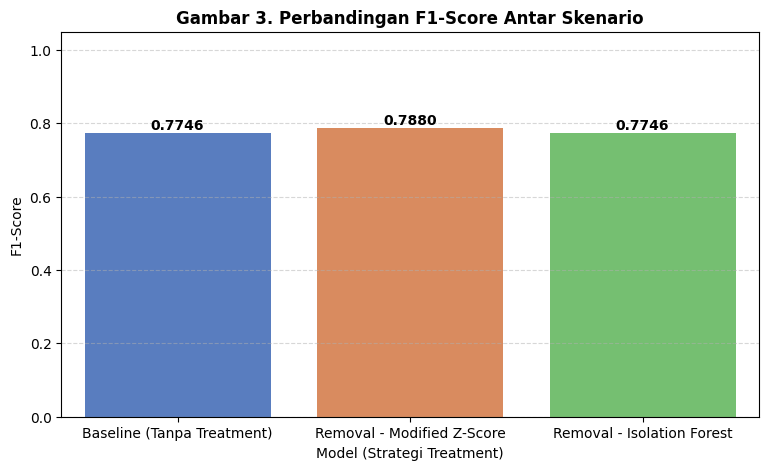

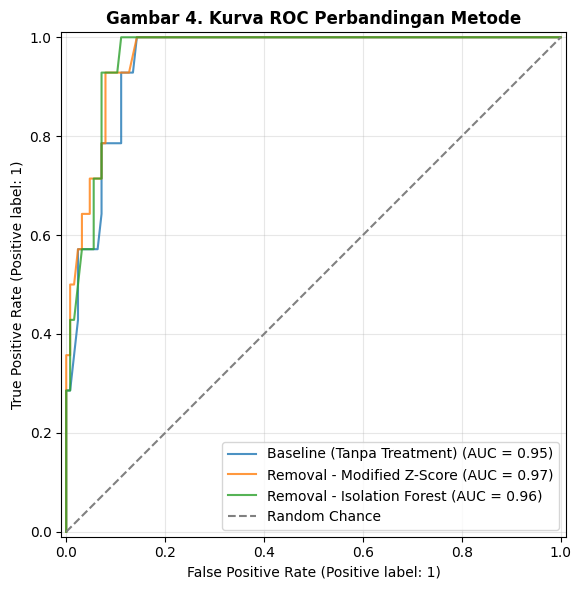

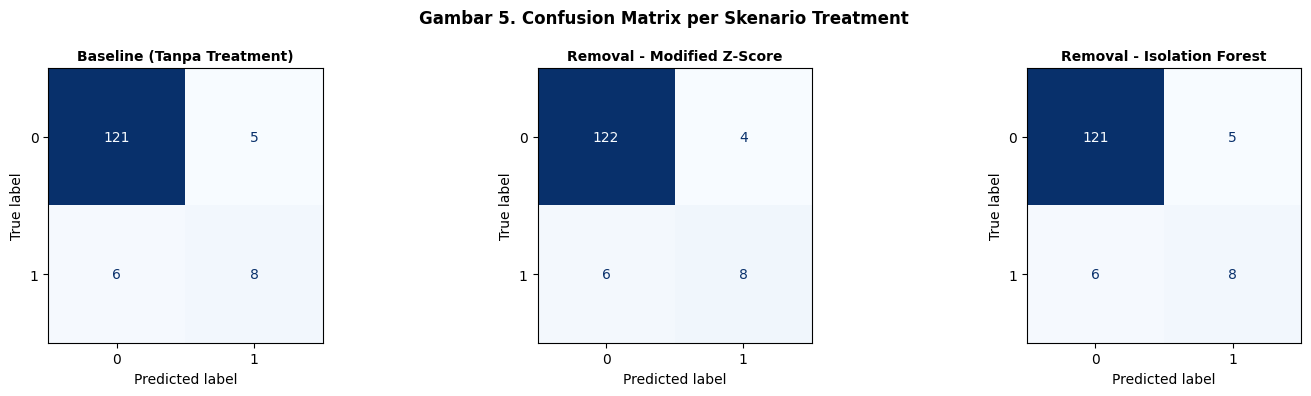

In [7]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

# 1. Bar Chart Perbandingan F1-Score
plt.figure(figsize=(9, 5))
sns.barplot(x='Model (Strategi Treatment)', y='F1-Score', data=df_hasil, palette='muted')
for index, row in df_hasil.iterrows():
    plt.text(index, row['F1-Score'] + 0.01, f"{row['F1-Score']:.4f}", color='black', ha="center", fontweight='bold')
plt.ylim(0, 1.05)
plt.title('Gambar 3. Perbandingan F1-Score Antar Skenario', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# 2. ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
for nama, model in model_tersimpan.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=nama, alpha=0.8)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Chance')
ax.set_title('Gambar 4. Kurva ROC Perbandingan Metode', fontweight='bold')
ax.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Confusion Matrix
fig, axes = plt.subplots(1, len(model_tersimpan), figsize=(5 * len(model_tersimpan), 4))
for i, (nama, mdl) in enumerate(model_tersimpan.items()):
    ConfusionMatrixDisplay.from_estimator(mdl, X_test, y_test, ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'{nama}', fontweight='bold', fontsize=10)
plt.suptitle('Gambar 5. Confusion Matrix per Skenario Treatment', fontweight='bold')
plt.tight_layout()
plt.show()